In [1]:
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline
import taichi as ti

# ti.init(
#     # arch=ti.cpu,
#     arch=ti.cuda,
#     default_fp=ti.f64,
#     cpu_max_num_threads=1,
#     offline_cache=False,
#     debug=True,
# )
# scaling = False
ti.init(
    # arch=ti.cpu,
    arch=ti.cuda,
    default_fp=ti.f32,
    cpu_max_num_threads=1,
    offline_cache=False,
    debug=True,
)
scaling = True

from pespace.detector.antenna import InterferometerAntenna, FDResponseModelMarset2018
from pespace.detector.tdi import TDIChannelData, FDMichelsonConstantEqualArm
from pespace.detector.orbit import KaplerianHeliocentric
from pespace.inference.interface_bilby import LikelihoodBilbyInterface
from tiwave.waveforms import IMRPhenomXAS, IMRPhenomXHM

import lal
import bilby

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=cuda


[I 02/05/26 10:03:28.528 157624] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout
/tmp/ipykernel_157624/2251914620.py:32: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Frequency-domain response

In [2]:
tdi_gen = "2.0"
tdi_chan = ("A", "E", "T")

delta_time = 10
num_tsamples = 2 ** np.ceil(np.log2(10 * lal.DAYJUL_SI / delta_time))
duration = num_tsamples * delta_time
print("sample num: ", num_tsamples)
print("duration: ", duration)

f_ref = 1e-4
f_min = 1e-4
f_max = 0.5*(1/delta_time)
t_start = 0.0

params = dict(
    total_mass=3e6,
    mass_ratio=0.6,
    chi_1=0.75,
    chi_2=0.62,
    luminosity_distance=56000.0,
    inclination=0.4,
    reference_phase=1.3,
    ecliptic_longitude=1.375,
    ecliptic_latitude=-1.2108,
    polarization=2.659,
    coalescence_time=0.0,
)
params = bilby.gw.conversion.generate_mass_parameters(params)
print(params)

sample num:  131072.0
duration:  1310720.0
{'total_mass': 3000000.0, 'mass_ratio': 0.6, 'chi_1': 0.75, 'chi_2': 0.62, 'luminosity_distance': 56000.0, 'inclination': 0.4, 'reference_phase': 1.3, 'ecliptic_longitude': 1.375, 'ecliptic_latitude': -1.2108, 'polarization': 2.659, 'coalescence_time': 0.0, 'mass_1': 1875000.0, 'mass_2': 1125000.0, 'chirp_mass': 1256226.717491785, 'symmetric_mass_ratio': np.float64(0.234375)}


In [3]:
tdi_data = TDIChannelData(scaling=scaling)
tdi_data.set_fd_data_from_zero(
    tdi_chan,
    duration,
    delta_time,
    start_time=t_start,
    minimum_frequency=f_min,
    maximum_frequency=f_max,
)

orbit_model = KaplerianHeliocentric(2.5e9, 0.0, 0.0)
response_model = FDResponseModelMarset2018()
tdi_combination = FDMichelsonConstantEqualArm(generation=tdi_gen, orthogonal=True)

lisa = InterferometerAntenna(
    name="lisa",
    tdi_data=tdi_data,
    orbit_model=orbit_model,
    response_model=response_model,
    tdi_combination=tdi_combination,
)


In [4]:
waveform_tiw = IMRPhenomXAS(
    tdi_data.frequency_samples, 
    f_ref, 
    scaling=scaling, 
    parameter_conversion=bilby.gw.conversion.generate_component_masses
    )
waveform_tiw.update_waveform(params)
lisa.update_detector_response(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:69: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


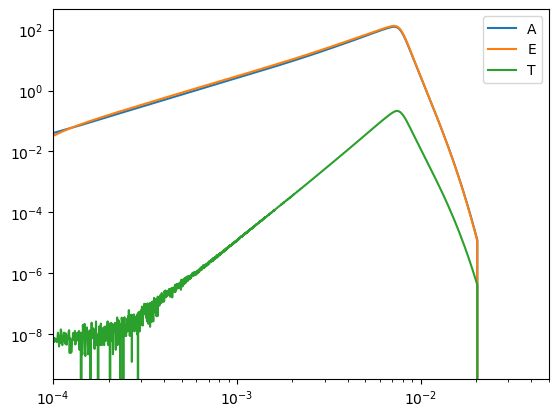

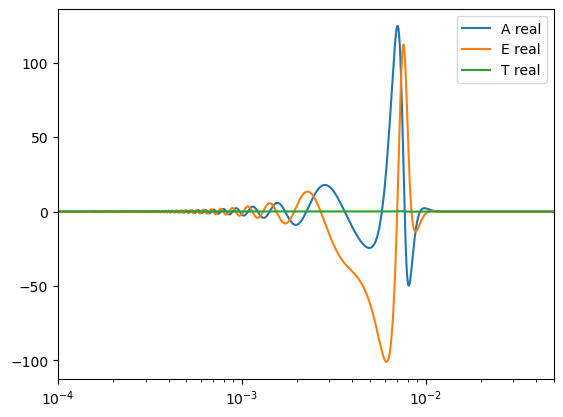

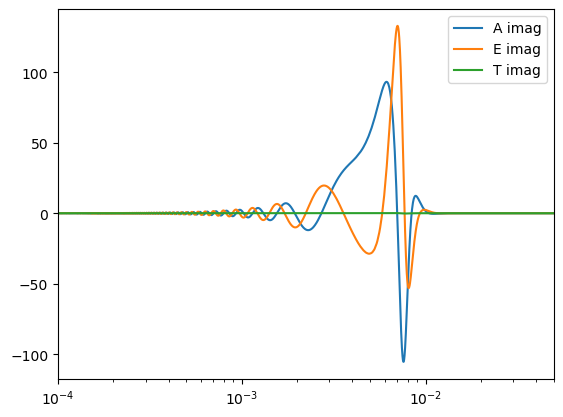

In [5]:
# abs
plt.figure()
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["A"]),
    label="A",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["E"]),
    label="E",
)
plt.loglog(
    lisa.tdi_data.data_info.frequency_samples_array,
    np.abs(lisa.tdi_response_numpy["T"]),
    label="T",
)
plt.xlim(f_min, f_max)
plt.legend()

# real part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].real,
    label="A real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].real,
    label="E real",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].real,
    label="T real",
)
plt.xlim(f_min, f_max)
plt.legend()

# imag part
plt.figure()
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["A"].imag,
    label="A imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["E"].imag,
    label="E imag",
)
plt.semilogx(
    lisa.tdi_data.data_info.frequency_samples_array,
    lisa.tdi_response_numpy["T"].imag,
    label="T imag",
)
plt.xlim(f_min, f_max)
plt.legend()

## PSD and noise realization

In [6]:
tdi_data.set_fd_noise_power_density_from_model("LISA_SciRDv1", tdi_generation=tdi_gen)
noise = tdi_data.get_fd_noise_realization()
tdi_data.add_into_fd_data(noise)


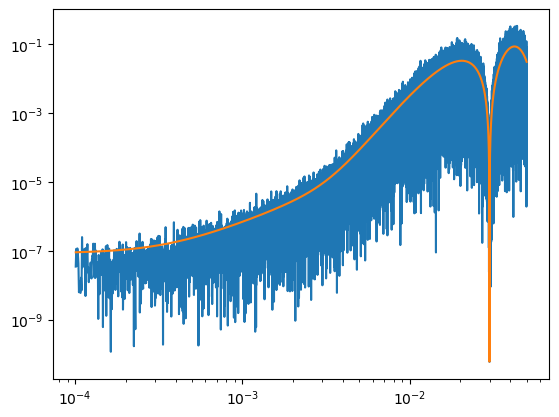

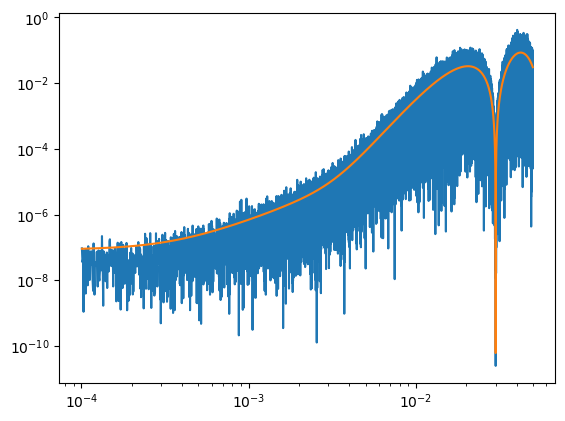

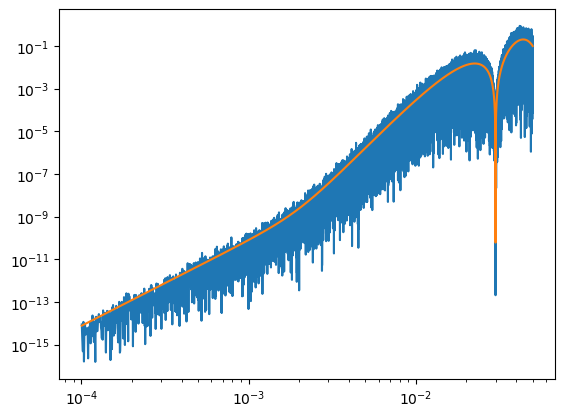

In [7]:
plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['A'])*tdi_data.fd_data_numpy['A']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['A'])

plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['E'])*tdi_data.fd_data_numpy['E']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['E'])

plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['T'])*tdi_data.fd_data_numpy['T']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['T'])

In [8]:
lisa.inject_signal(
    waveform_tiw.waveform_container,
    params["ecliptic_longitude"],
    params["ecliptic_latitude"],
    params["polarization"],
    params["coalescence_time"],
)


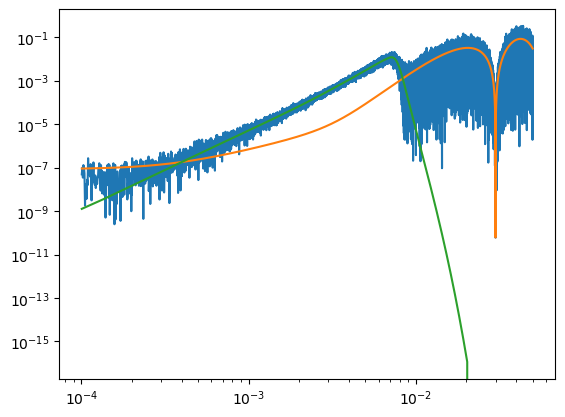

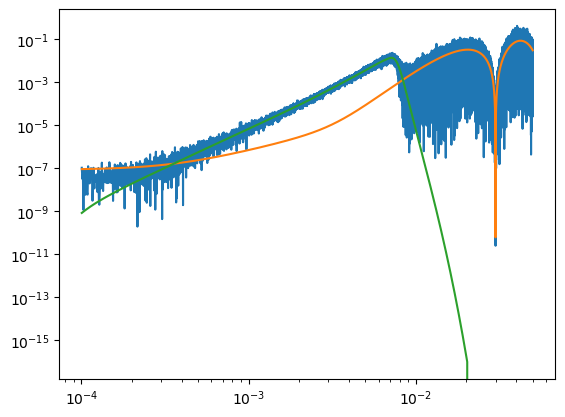

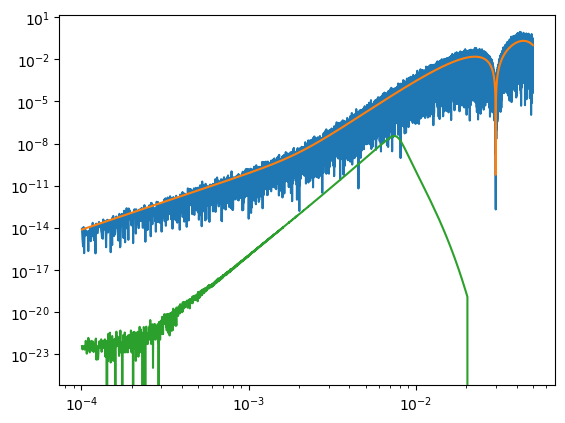

In [9]:
plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['A'])*tdi_data.fd_data_numpy['A']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['A'])
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(lisa.tdi_response_numpy["A"])*lisa.tdi_response_numpy["A"]*tdi_data.data_info.delta_frequency).real)

plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['E'])*tdi_data.fd_data_numpy['E']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['E'])
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(lisa.tdi_response_numpy["E"])*lisa.tdi_response_numpy["E"]*tdi_data.data_info.delta_frequency).real)

plt.figure()
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(tdi_data.fd_data_numpy['T'])*tdi_data.fd_data_numpy['T']*tdi_data.data_info.delta_frequency).real)
plt.loglog(tdi_data.data_info.frequency_samples_array,
           tdi_data.fd_noise_power_density_numpy['T'])
plt.loglog(tdi_data.data_info.frequency_samples_array,
           (np.conj(lisa.tdi_response_numpy["T"])*lisa.tdi_response_numpy["T"]*tdi_data.data_info.delta_frequency).real)


## Likelihood

In [10]:
likelihood = LikelihoodBilbyInterface(
    waveform=waveform_tiw,
    detector=lisa,
    channels=('A', 'E', 'T')
    # channels=('A',)
    )

In [11]:
params.pop('total_mass', None)
params.pop('mass_1', None)
params.pop('mass_2', None)
params.pop('symmetric_mass_ratio', None)
params

{'mass_ratio': 0.6,
 'chi_1': 0.75,
 'chi_2': 0.62,
 'luminosity_distance': 56000.0,
 'inclination': 0.4,
 'reference_phase': 1.3,
 'ecliptic_longitude': 1.375,
 'ecliptic_latitude': -1.2108,
 'polarization': 2.659,
 'coalescence_time': 0.0,
 'chirp_mass': 1256226.717491785}

In [12]:
likelihood.parameters.update(params)
ll = likelihood.log_likelihood()
ll
# x64_f32: -196407.375
# x64_f64: -195959.13797419413
# cuda_f32: -196844.859375
# cuda_f64: -196802.10506417905


-195931.515625

In [13]:
num = 1000
params_samples = {
    'chi_1': np.linspace(-0.99, 0.99, num),
    'chi_2': np.linspace(-0.99, 0.99, num),
    'ecliptic_longitude': np.linspace(0.0, 2*np.pi, num),
    'ecliptic_latitude': np.linspace(-np.pi/2, np.pi/2, num),
    'inclination': np.linspace(0.0, np.pi, num),
    'polarization': np.linspace(0.0, np.pi, num),
    'reference_phase': np.linspace(0.0, 2*np.pi, num),
    'coalescence_time': np.linspace(-100, 100, num),
    'chirp_mass': np.linspace(5e5, 2e6, num),
    'mass_ratio': np.linspace(0.05, 0.99, num),
    'luminosity_distance': np.exp(np.linspace(np.log(1e4), np.log(1e6), num)),
}

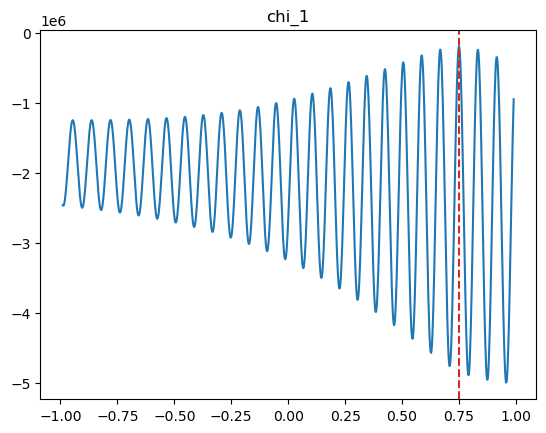

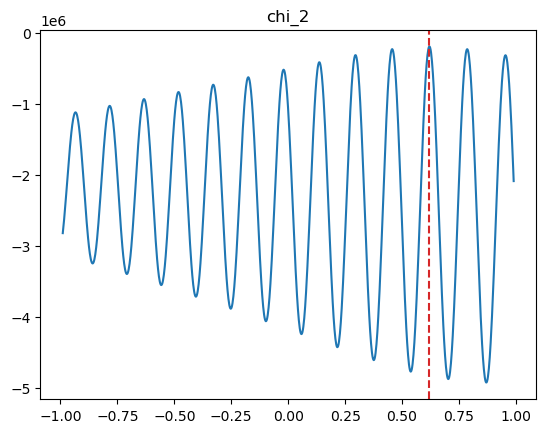

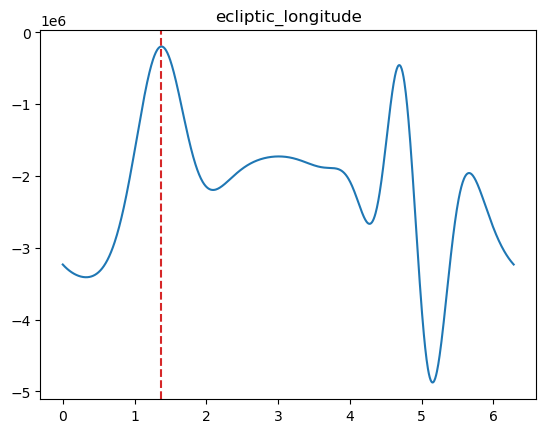

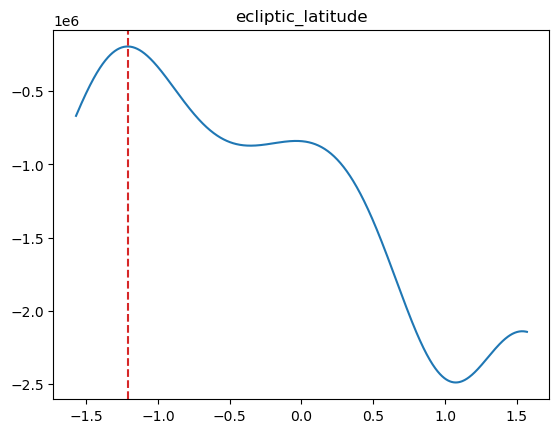

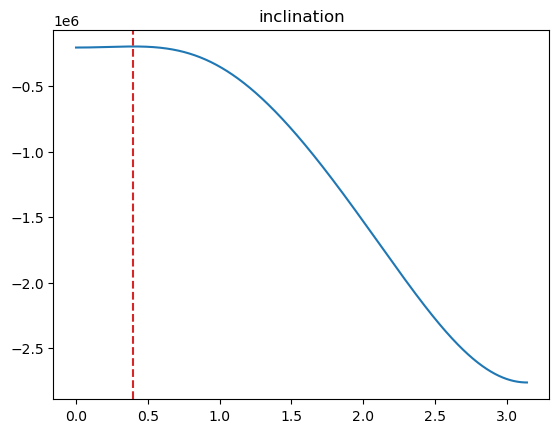

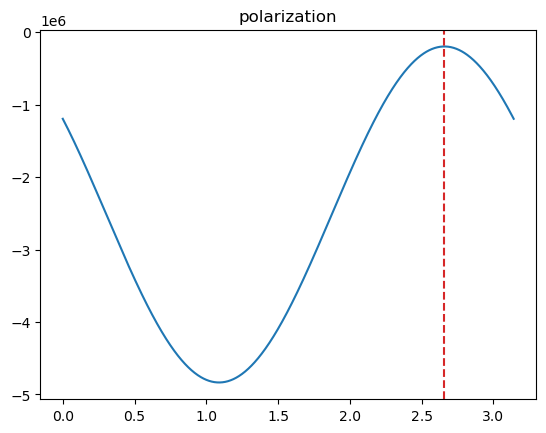

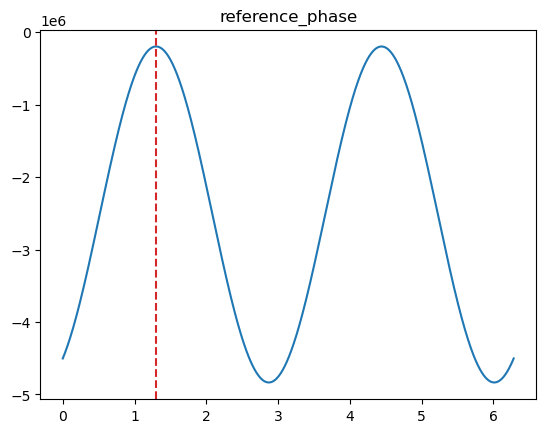

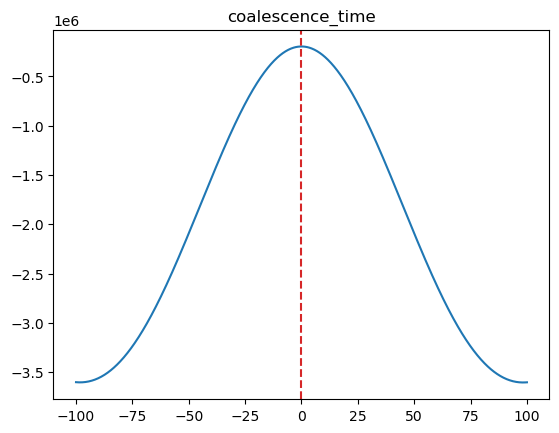

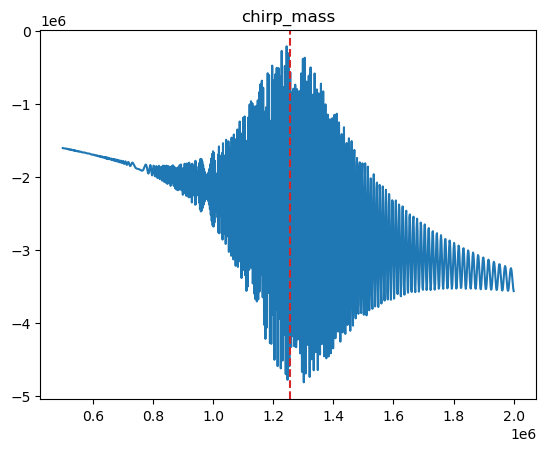

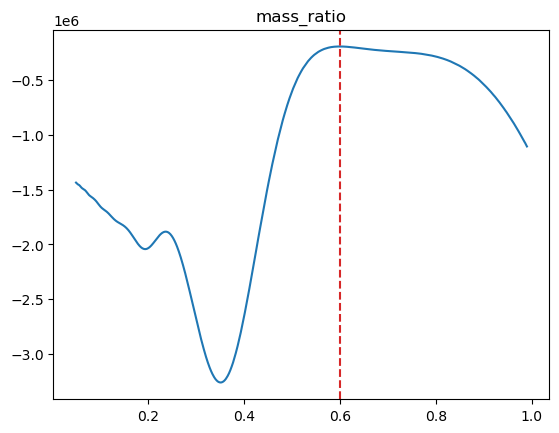

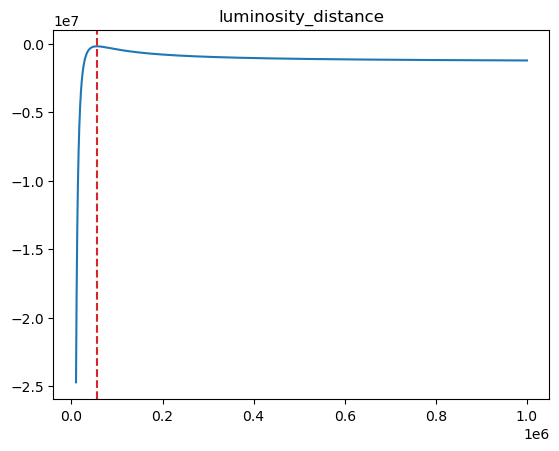

In [14]:
for key, samples in params_samples.items():
    ll_samples = np.zeros(num)
    input_params = params.copy()

    for i in range(num):
        input_params.update({key: samples[i]})
        likelihood.parameters.update(input_params)
        ll_samples[i] = likelihood.log_likelihood()
    
    plt.figure()
    plt.title(key)
    plt.plot(samples, ll_samples)
    plt.axvline(params[key], linestyle='dashed', color='tab:red')
